# LSTM Model
All data loading, feature engineering, and training infrastructure is identical to `FinalProject-1.ipynb`.
Only the **model class** and its usage are changed — all changes are commented inline.

In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt


# Settings
INTERVAL_SECONDS = 10
EPOCHS = 10
BATCH_SIZE = 64


# Load data
train = pd.read_csv("train.csv")
train = train.dropna(subset=["target"])
train["label"] = (train["target"] > 0).astype(int)


def group_time_intervals(df, interval_seconds):
    df = df.copy()
    df["time_group"] = (df["seconds_in_bucket"] // interval_seconds) * interval_seconds
    grouped = df.groupby(["stock_id", "date_id", "time_group"], as_index=False).agg({
        "seconds_in_bucket": "last",
        "imbalance_size": "mean",
        "imbalance_buy_sell_flag": "last",
        "reference_price": "last",
        "matched_size": "mean",
        "far_price": "last",
        "near_price": "last",
        "bid_price": "last",
        "bid_size": "mean",
        "ask_price": "last",
        "ask_size": "mean",
        "wap": "last",
        "target": "last",
        "label": "last"
    })
    return grouped

train = group_time_intervals(train, INTERVAL_SECONDS)

train["bid_ask_spread"]          = train["ask_price"] - train["bid_price"]
train["mid_price"]               = (train["ask_price"] + train["bid_price"]) / 2
train["imbalance_ratio"]         = train["imbalance_size"] / (train["matched_size"] + 1)
train["wap_reference_diff"]      = train["wap"] - train["reference_price"]
train["wap_mid_diff"]            = train["wap"] - train["mid_price"]
train["size_ratio"]              = train["bid_size"] / (train["ask_size"] + 1)
train["matched_imbalance_ratio"] = train["matched_size"] / (train["imbalance_size"] + 1)


def add_sequence_features(df):
    df = df.sort_values(["stock_id", "date_id", "seconds_in_bucket"]).copy()
    grp = df.groupby(["stock_id", "date_id"])
    df["wap_lag1"]        = grp["wap"].shift(1)
    df["wap_return"]      = df["wap"] / (df["wap_lag1"].replace(0, np.nan) + 1e-8) - 1
    df["imbalance_roll3"] = grp["imbalance_ratio"].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df["spread_roll3"]    = grp["bid_ask_spread"].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df["wap_roll_std"]    = grp["wap"].transform(lambda x: x.rolling(5, min_periods=1).std())
    return df.fillna(0)

train = add_sequence_features(train)

features = [
    "seconds_in_bucket", "imbalance_size", "imbalance_buy_sell_flag",
    "matched_size", "bid_size", "ask_size", "wap",
    "bid_ask_spread", "imbalance_ratio", "wap_reference_diff",
    "wap_mid_diff", "size_ratio", "matched_imbalance_ratio",
    "wap_return", "imbalance_roll3", "spread_roll3", "wap_roll_std",
]

train[features] = train[features].replace([np.inf, -np.inf], np.nan).fillna(0)

SEQ_LEN = 55

unique_dates = sorted(train["date_id"].unique())
split        = int(0.8 * len(unique_dates))
train_dates  = unique_dates[:split]
val_dates    = unique_dates[split:]

train_df = train[train["date_id"].isin(train_dates)].copy()
val_df   = train[train["date_id"].isin(val_dates)].copy()

scaler = StandardScaler()
train_df[features] = scaler.fit_transform(train_df[features])
val_df[features]   = scaler.transform(val_df[features])


class StockDataset(Dataset):
    def __init__(self, df):
        self.X, self.y = [], []
        for _, g in df.groupby(["stock_id", "date_id"]):
            g = g.sort_values("seconds_in_bucket")
            # Keep any sequence >= SEQ_LEN, take the last SEQ_LEN rows
            # (avoids silently dropping stocks with minor row-count differences)
            if len(g) >= SEQ_LEN:
                self.X.append(g[features].values[-SEQ_LEN:])
                self.y.append(g["label"].iloc[-1])
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.long)

    def __len__(self):  return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


train_dataset = StockDataset(train_df)
val_dataset   = StockDataset(val_df)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def get_optimizer_and_scheduler(model):
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.001, epochs=EPOCHS,
        steps_per_epoch=len(train_loader), pct_start=0.3, anneal_strategy="cos"
    )
    return optimizer, scheduler

label_counts   = train_df["label"].value_counts().sort_index()
class_weights  = torch.tensor([1.0/label_counts[0], 1.0/label_counts[1]], dtype=torch.float32).to(device)
class_weights /= class_weights.sum()
loss_fn        = nn.CrossEntropyLoss(weight=class_weights)


Using device: cpu


In [2]:
def train_model(model):
    optimizer, scheduler = get_optimizer_and_scheduler(model)
    train_losses, val_losses, val_accuracies, val_aucs = [], [], [], []

    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss    = loss_fn(outputs, y_batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_val_loss, all_preds, all_labels, all_probs = 0, [], [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs  = model(X_batch)
                loss     = loss_fn(outputs, y_batch)
                total_val_loss += loss.item()
                probs    = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                preds    = torch.argmax(outputs, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y_batch.cpu().numpy())
                all_probs.extend(probs)  # probabilities used for AUC

        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = accuracy_score(all_labels, all_preds)
        val_auc      = roc_auc_score(all_labels, all_probs)  # AUC measures ranking quality

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
        val_aucs.append(val_auc)

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Acc: {val_accuracy:.4f} | AUC: {val_auc:.4f}")

    # ── Plots ──
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(train_losses, label="Train"); axes[0].plot(val_losses, label="Val")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[1].plot(val_accuracies); axes[1].set_title("Val Accuracy")
    axes[2].plot(val_aucs);       axes[2].set_title("Val AUC-ROC")
    plt.tight_layout(); plt.show()

    print("\nFinal Val Accuracy:", round(val_accuracies[-1], 4))
    print("Final Val AUC:     ", round(val_aucs[-1], 4))
    print()
    print(classification_report(all_labels, all_preds))
    return val_accuracies[-1], val_aucs[-1]


## Model Definition & Training
See inline comments for what changed vs the baseline GRU and why.

Epoch 1 | Train Loss: 0.6874 | Val Loss: 0.6555 | Acc: 0.6177 | AUC: 0.6545
Epoch 2 | Train Loss: 0.6664 | Val Loss: 0.6531 | Acc: 0.6200 | AUC: 0.6594
Epoch 3 | Train Loss: 0.6636 | Val Loss: 0.6509 | Acc: 0.6199 | AUC: 0.6628
Epoch 4 | Train Loss: 0.6620 | Val Loss: 0.6510 | Acc: 0.6182 | AUC: 0.6655
Epoch 5 | Train Loss: 0.6606 | Val Loss: 0.6501 | Acc: 0.6226 | AUC: 0.6664
Epoch 6 | Train Loss: 0.6587 | Val Loss: 0.6487 | Acc: 0.6226 | AUC: 0.6679
Epoch 7 | Train Loss: 0.6573 | Val Loss: 0.6473 | Acc: 0.6243 | AUC: 0.6695
Epoch 8 | Train Loss: 0.6561 | Val Loss: 0.6475 | Acc: 0.6236 | AUC: 0.6697
Epoch 9 | Train Loss: 0.6545 | Val Loss: 0.6470 | Acc: 0.6245 | AUC: 0.6701
Epoch 10 | Train Loss: 0.6539 | Val Loss: 0.6470 | Acc: 0.6251 | AUC: 0.6700


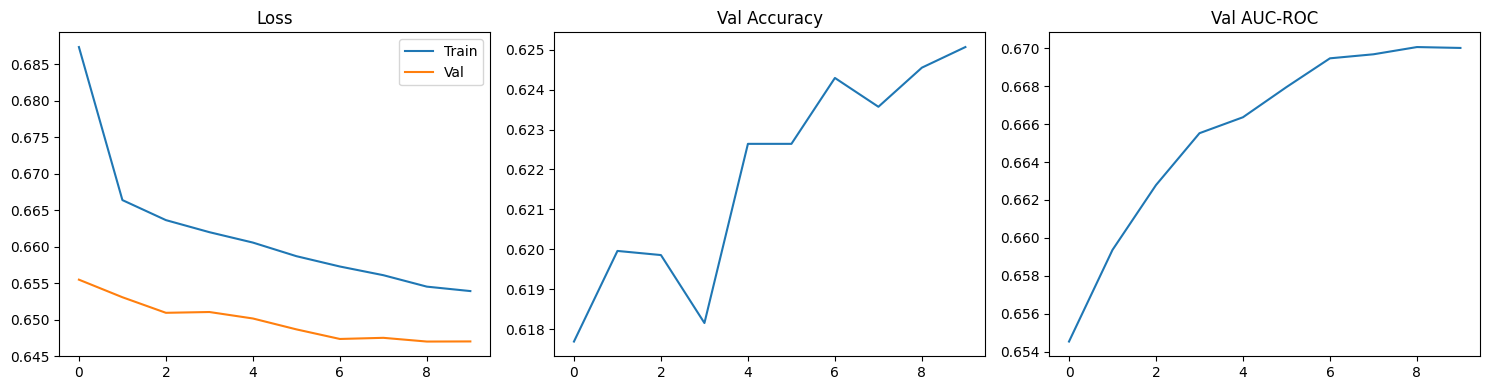


Final Val Accuracy: 0.6251
Final Val AUC:      0.67

              precision    recall  f1-score   support

           0       0.63      0.65      0.64      9847
           1       0.62      0.60      0.61      9551

    accuracy                           0.63     19398
   macro avg       0.62      0.62      0.62     19398
weighted avg       0.63      0.63      0.62     19398

LSTM — Accuracy: 0.6251  AUC: 0.6700


In [3]:
class LSTMModel(nn.Module):
    # CHANGED: swapped nn.GRU for nn.LSTM
    # LSTM adds a separate "cell state" on top of the hidden state, giving it
    # two memory pathways. This can capture longer-range dependencies than a GRU
    # but uses ~33% more parameters. Good to compare against GRU to see if the
    # extra capacity helps on this 55-step sequence.
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(            # CHANGED: GRU → LSTM
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 2)
        )

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)   # CHANGED: LSTM returns (output, (h_n, c_n))
        last_hidden = hidden[-1]        # take the top-layer hidden state, same as GRU
        return self.head(last_hidden)


model = LSTMModel(input_size=len(features)).to(device)
acc, auc = train_model(model)
print(f"LSTM — Accuracy: {acc:.4f}  AUC: {auc:.4f}")
